<a href="https://colab.research.google.com/github/manaraza/SatelliteDataAI-UOA/blob/main/761_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Deep Learning for Satellite Data
This notebook uses a pre-made training dataset to develop a simple deep learning classifier for finding solar pannels in Sentinel 2 imagery. The learning objectives for this lab are to:

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes).
2. Prepare that data for use in a deep learning model.
3. Train a deep learning model in TensorFlow/Keras using these labels.

At the end of the lab you will be asked to reflect on model performance, generalization, and sources of error.


In [8]:
# Set up, couple of new libraries here so expect install times to take longer than you have been used to
!pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

import os
import zipfile
from pathlib import Path
import numpy as np
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from sklearn.model_selection import train_test_split


In [9]:
# Set our random seeds for reproducibility
SEED = 42 #<- the meaning of life, this is why you always see people setting seeds to 42 by the way... (Douglas Adamns, Hitchhikers Guide to the Galaxy)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Your training data has been downloaded from:

*   [Solafune](https://solafune.com/competitions/5dfc315c-1b24-4573-804f-7de8d707cd90?id=&menu=data&topicId=54728653-0e25-4975-baad-6fe2f5185844)

Find the data on Canvas or download directly from their website the 'train.zip'. The competition that this dataset was created for is now over, but that is good for us as it means you can look at the winning solutions for inspiration!

If you want to download the data yourself you will need to sign up for an account and then 'enter' the competition. You can do this all without charge but it does require an email address sign up.

We are just going to use the 'train.zip' data and split that into our train and test, in order to reduce the burden on our notebooks. Remember that ultimately we would want to validate it, and you will see that the linked data source actually has a completely seperate store of images for that purpose.

Download the 'train.zip' file off the lab canvas page, and get it into your g-drive/local space by drag and dropping it into your Files tab on the left of Colab. Leave it zipped.

**Wait for it to upload fully before you run the next cell.** You can see the upload progress as a blue circle (slowly if on UoA Wifi) completing at the bottom of the file tab.


In [10]:
# Assume train.zip is already uploaded to Colab file store, extract it
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

With our data extracted, we now need to build lists of each sample patch and the labelled mask of it, connecting the two. I have written this relatively robustly (e.g. you can set it to handle different file extensions and it checks that it is finding the correct files), so that hopefully you can use it more widely than just in this lab.

In [12]:
# Set the file extenion we are using
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: /content/train_data/s2_image
Found mask dir: /content/train_data/mask
Found 2066 valid paired samples.
Example pair: (PosixPath('/content/train_data/s2_image/train_s2_image_0.tif'), PosixPath('/content/train_data/mask/train_mask_0.tif'))


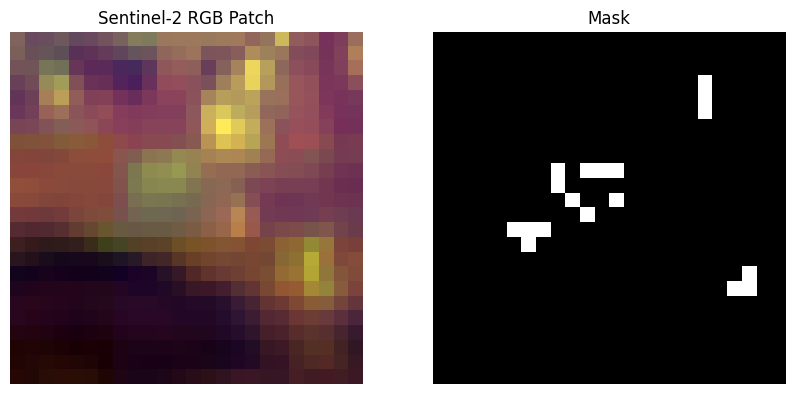

In [13]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that you have different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  # RGB bands for Sentinel-2 (B4, B3, B2)
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

Ok, that does not look like much... but for now let's hope that these label and image pairs are good...

Next up we are going to prepare our training data into numpy arrays that are then able to be passed into TensorFlow. However, if we try to hold all 2000+ patches in RAM whilst we do, the Colab instance will crash. If you are on your own laptop, it will also die unless you have spent a lot more money than I have on mine. Furthermore, even if we had a HPC level of RAM available it is a good idea to do things in a 'memory safe' manner that means we can scale our training with more samples if we so deisred it.

The safe pattern is therefore to:
1. Load a batch of patches.
2. Normalize/resize them.
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5).
4. Free memory and move on.
5. Then later, when training, you stream batches directly from disk.

Below is a disk-based pipeline with batching using numpy.savez_compressed (safe and easy to reload):

In [14]:
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

# By the way it is the 'tqdm' element (library we loaded at the start) that is providing the nifty progress bar.
# I always like to include it when waiting for things so that I know it is actually running.

# This block might take five to ten minutes to run as we are doing this in a linear manner (rather than parallell processing).
# An optimised version of thise code is to pass each batch to a seperate CPU thread/core.

Processing: 100%|██████████| 2066/2066 [08:02<00:00,  4.28it/s]


5-10 minutes later... (mine took 8 minutes and 32 seconds), we can now move on. Because we are now not storing our training data in our RAM like we did in the lecture exercise, we have to load it in as we want it.

Ok, with our training data ready. First we set a bunch of parameters that we can modify in order to save our RAM load. In short, the lower these values the less RAM you will use but the worse the results:

In [15]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2

**Q1**: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

In [16]:
# Q1 check: how many bands does this dataset actually provide?
import rasterio
with rasterio.open(pairs[0][0]) as src:
    print("Bands in this dataset:", src.count)

Bands in this dataset: 12


# **Answer:**
Sentinel-2 carries 13 spectral bands (B1-B12 plus B8A). This dataset provides 12 bands per patch, because it is a Level-2A surface reflectance product: B10 (cirrus) is used during atmospheric correction and is not delivered in the output. So up to 12 bands could be fed to the CNN, rather than the 3 (RGB) used here. Also, the lab restricts input to RGB purely to reduce memory load. Including the NIR and SWIR bands would likely improve detection, since solar panels are spectrally distinctive outside the visible range.

Next we find our patch files:

In [17]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

**Q2**: What is the total number of patches in our training data and the total number in our validation set? (With the parameters set as I have done in the notebook).

Tip: you can either programmatically count what is in train_files/val_files, or you can calculate it from the parameters that have been set across the cells above this one.

In [18]:
# Q2 check: count the actual patches in each split
def count_samples(files):
    return sum(np.load(f)["X"].shape[0] for f in files)

print("Number of .npz files total:", len(all_files))
print("Train files:", len(train_files), "-> patches:", count_samples(train_files))
print("Val files:  ", len(val_files),   "-> patches:", count_samples(val_files))

Number of .npz files total: 21
Train files: 5 -> patches: 500
Val files:   2 -> patches: 200


# **Answer:**
Training: 500 patches, Validation: 200 patches
Derivation: the 2066 paired samples were written to disk in batches of BATCH_SIZE = 100, which produced 21 .npz files. The RAM parameters then set MAX_TRAIN_FILES = 5 and MAX_VAL_FILES = 2, so 500 patches are used for training, and 200 patches for validation, as confirmed by count_samples().
This means only 700 of the 2066 available patches are used at all; the rest are discarded.

We then we need to change our masks to a binary label. If we were doing segmenation we would keep it as a mask, but in this case we are just trying to find patches that contain solar pannels rather than the specific solar pannel outline.

In [19]:
# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Now we need a tool to load our data in from the batched files:

In [20]:
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y

We can now define our training and validation datasets, which will only be actually populated with data as required, rather than loading it all into memory at once.

In [21]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

**Q3**: Are we shuffling the **training** dataset? Are we shuffling the **validation** dataset?

# **Answer:**
Training: yes, Validation:no
make_cls_dataset is called with shuffle=True for the training set and shuffle=False for validation. When shuffling is enabled the function shuffles twice, firstly the list of .npz files, then a buffer of 2048 individual saples after they are streamed in.
Training data is shuffled so that each batch contains a varied, unordered mix of samples. If the model saw data in a fixed order it could learn patterns from the sequence itself, and gradient updates would be biased by whatever happens to be grouped together in a file. Shuffling makes each batch a more representative sample of the whole dataset.
Validation data is not shuffled, because its purpose is measurement mainly not learning. No weights are updated from it, so ordering has no effect on the result, and keeping it fixed makes the evaluation reproducible and comparable between epochs and between runs.

Finally, we need to specify our model settings. We are just using a simple CNN here, the same sort as we used the lecture exercise. But, this time it has signficantly more layers and therefore parameters (but far less than you might use for your project). It may take a few minutes to set up:

In [22]:
# We are determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

**Q4**: Which type of activation funding is our final layer using and why are we using this function as our final layer?

# Answer
The final layer uses a **sigmoid** activation: layers.Dense(1, activation='sigmoid').
Sigmoid squashes any real-valued input into the range 0 to 1, so the single output neuron can be interpreted as a probability. Here, the probability that a patch contains a solar panel. This suits the task because it is a binary classification: each patch either contains a panel or does not, so one output between 0 and 1 is sufficient, with a threshold (typically 0.5) converting it into a decision.
Sigmoid also pairs correctly with the chosen loss function, binary_crossentropy, which expects probabilities in [0,1]. For a multi-class problem, we would instead use softmax across several output neurons, and for a regression output, we would use no activation function at all.

With the model ready to train, we have one more preperation step to make. We need to count the total samples available in this particular run. This is because you can change the number of samples via the RAM paramaters earlier, and therefore we should assume in this code a static number of samples will always be available when setting our number of steps per epoch.

In [23]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        total += np.load(f)["X"].shape[0]
    return total

n_train = count_samples(train_files)
n_val   = count_samples(val_files)

steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)

Finally, we train the model! It should take 5-10 minutes to run on a free-user Colab notebook.

In [24]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 166ms/step - accuracy: 0.9280 - loss: 0.3222 - val_accuracy: 0.9150 - val_loss: 0.2967
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 161ms/step - accuracy: 0.9340 - loss: 0.2595 - val_accuracy: 0.9150 - val_loss: 0.2985
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - accuracy: 0.9340 - loss: 0.2585 - val_accuracy: 0.9150 - val_loss: 0.2956
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 246ms/step - accuracy: 0.9340 - loss: 0.2547 - val_accuracy: 0.9150 - val_loss: 0.3065
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 211ms/step - accuracy: 0.9340 - loss: 0.2553 - val_accuracy: 0.9150 - val_loss: 0.3128


Visualizie the predictions:

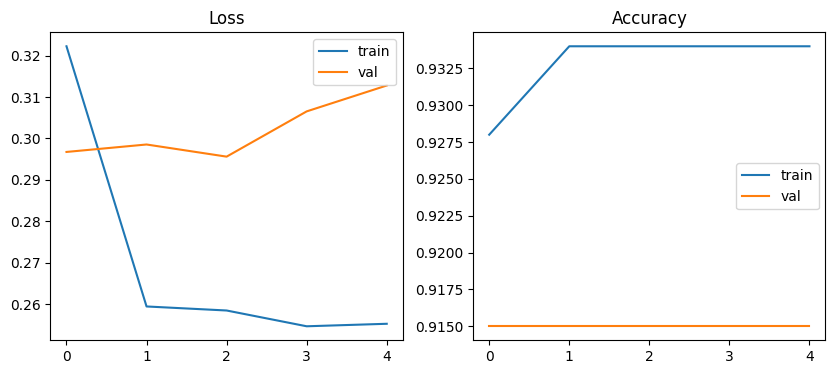

In [25]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

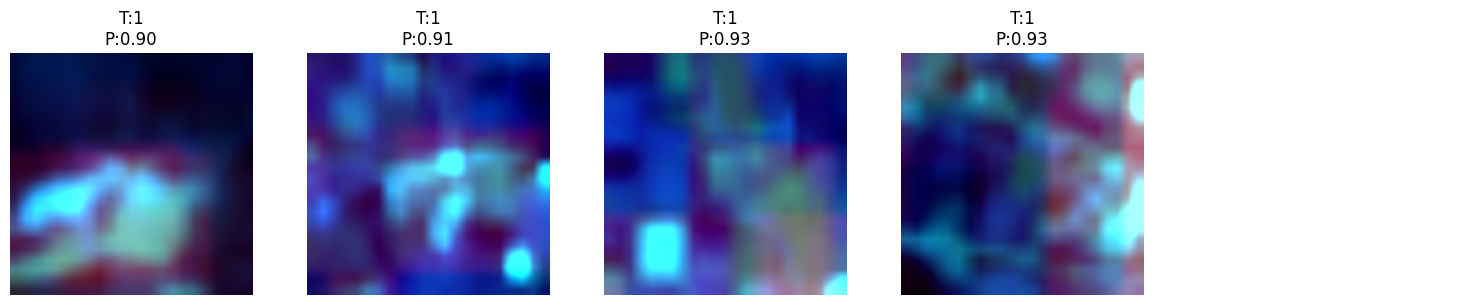

In [26]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Remembering that this is a effectively still a toy CNN with tiny data, we can see that we have built a model that gives us a probability of the patches containing a solar pannel. We know that for all of the patchs used in this training, the answer is true...

In [27]:
#base-rate check for q5
import numpy as np
for name, files in [('train', train_files), ('val', val_files)]:
    labels = []
    for f in files:
        Y = np.load(f)["Y"]
        labels.append((np.sum(Y, axis=(1,2,3)) > 0).astype(int))
    labels = np.concatenate(labels)
    print(f"{name}: {labels.mean()*100:.1f}% positive ({labels.sum()}/{len(labels)})")

train: 93.4% positive (467/500)
val: 91.5% positive (183/200)


**Q5**: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

# Answer
No. The model is not robust, and its apparently high accuracy is misleading.
The critical flaw is in the training data design. This dataset was built for segmentation, so patches were included precisely because they contain solar panels. Converting the masks to binary patch-level labels therefore produces an extremely imbalanced set: 93.4% of training patches (467/500) and 91.5% of validation patches (183/200) are positive. With so few negatives, the trivially optimal strategy is to ignore the imagery entirely and always predict "panel present".
The performance statistics show, this is exactly what happened.
Training accuracy is 0.9340 and validation accuracy 0.9150, identical to the positive rates in each split. Both metrics are also completely falt from epoch 1 onward, whereas a model genuinely learning would show continued movement. The prediction grid confirms it: every patch receives a near-identical probability (0.90-0.93), clustered around the base rate, regardless of image content. The model is outputting a constant, not discriminating.
Also, the training curves show no useful learning either. Training loss falls then plateaus, while validation loss rises from epoch 2 (0.295 leads to 0.313), indicating the model has begun overfitting rather than generalising.
Further weaknesses in the CNN configuration compound this. The network has only 6,177 parameters across two convolutional layers, extremely small for image classification.
GlobalAveragePooiling2D collapses each feature map to a single value, discarding spatial detail that matters when a solar panel may occupy only a handful of 10m pixels. Only 3 of the 12 available bands are used, omitting the NIR and SWIR bands where panels are most spectrally distinctive. Training used just 500 of 2066 available patches for 5 epochs, and the model includes no dropout or regularisation.
As far as unseen imagery is concerned, it would be overwhelmingly negative since solar panels are rare across a landscape, this model would flag almost everything as containing a panel, producing a false-positive rate approaching 100%. Its high lab accuracy is entirely an artefact of an unrepresentative test distribution.

**Q6**: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:
*   A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
*   A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

You do not need to create a 100% solution here. I am looking for you to demonstrate an understanding of the critical design flaw in this training set (particularly for a patch based, as opposed to segmentation, approach), and to show critical thinking in how you might fix it. This may include re-sampling the existing training data, including new training data, or changing the bands being used (or all of the above).



In [31]:
# Q6: Re-design the training data

import numpy as np, glob

CROP = 64           # sub-patch size (64x64 px at 10 m = 640 m on the ground)
MIN_SOLAR_PX = 5    # a sub-patch needs a meaningful panel presence to count positive

def mine_subpatches(files, crop=CROP, per_patch=6, seed=42, min_px=MIN_SOLAR_PX):
    """Split each 256x256 patch into random sub-patches.
       POSITIVE  : mask region contains >= min_px solar pixels
       NEGATIVE  : mask region contains exactly 0 solar pixels
       DISCARDED : 1..min_px-1 pixels (ambiguous edge clips - noisy labels)

       Image and mask are cropped at identical offsets, so they stay aligned.
       This creates genuine negatives from the same sensor, atmospheric processing
       and geography as the positives, so there is no domain shift."""
    rng = np.random.default_rng(seed)
    neg, pos, discarded = [], [], 0
    for f in files:
        d = np.load(f)
        X, Y = d['X'], d['Y']
        for i in range(X.shape[0]):
            for _ in range(per_patch):
                r = rng.integers(0, X.shape[1] - crop)
                c = rng.integers(0, X.shape[2] - crop)
                sub_x = X[i, r:r+crop, c:c+crop, :]
                sub_y = Y[i, r:r+crop, c:c+crop, :]      # same offsets -> aligned
                s = sub_y.sum()
                if s >= min_px:
                    pos.append(sub_x)
                elif s == 0:
                    neg.append(sub_x)
                else:
                    discarded += 1
    print(f"Discarded {discarded} ambiguous sub-patches (1-{min_px-1} solar pixels)")
    return np.array(neg, dtype=np.float32), np.array(pos, dtype=np.float32)

source_files = all_files[:12]
neg_patches, pos_patches = mine_subpatches(source_files)
print(f"Mined {len(neg_patches)} negatives and {len(pos_patches)} positives")

#Balance to 50/50
n = min(len(neg_patches), len(pos_patches))
X_bal = np.concatenate([neg_patches[:n], pos_patches[:n]])
Y_bal = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)

rng = np.random.default_rng(42)
idx = rng.permutation(len(X_bal))
X_bal, Y_bal = X_bal[idx], Y_bal[idx]
print(f"Balanced set: {len(X_bal)} patches, {Y_bal.mean()*100:.1f}% positive")

#Save train/val splits in the same .npz format the pipeline expects
split = int(0.75 * len(X_bal))
np.savez_compressed('balanced_train.npz', X=X_bal[:split], Y=Y_bal[:split])
np.savez_compressed('balanced_val.npz',   X=X_bal[split:], Y=Y_bal[split:])
print(f"Saved: {split} train / {len(X_bal)-split} val")

Discarded 7 ambiguous sub-patches (1-4 solar pixels)
Mined 3891 negatives and 3098 positives
Balanced set: 6196 patches, 50.0% positive
Saved: 4647 train / 1549 val


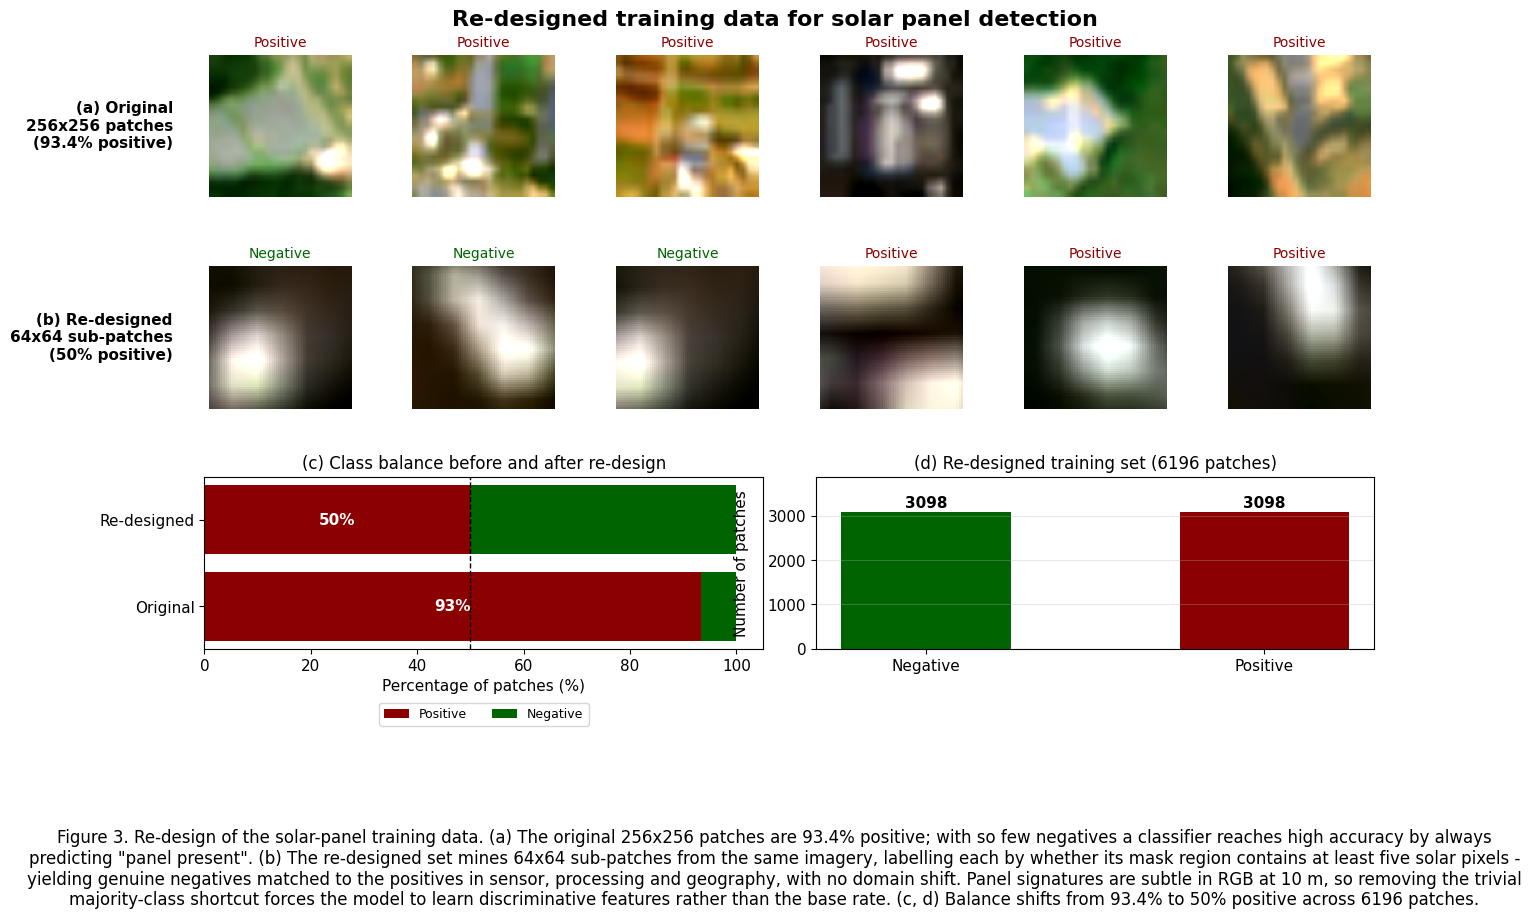

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Q6 Figure: re-designed patches vs. original patches

import matplotlib.pyplot as plt
import numpy as np

def stretch(img):
    """Contrast stretch RGB to 0-1 for display."""
    img = img.astype(np.float32)
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

def structure_score(tile):
    """Mean gradient magnitude - favours tiles with edges, boundaries, roofs
       rather than featureless ones, so the displayed examples show real detail."""
    rgb = tile[:, :, [3, 2, 1]].mean(axis=2)
    return np.abs(np.diff(rgb, axis=0)).mean() + np.abs(np.diff(rgb, axis=1)).mean()

orig_pos_rate = 93.4
new_pos_rate  = Y_bal.mean() * 100

plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(3, 6, height_ratios=[1, 1, 1.2], hspace=0.45, wspace=0.35)

#Row 1: original patches (all positive)
d0 = np.load(source_files[0])
for j in range(6):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(stretch(d0['X'][j, :, :, [3,2,1]].transpose(1,2,0)),
              interpolation='nearest')
    ax.set_title('Positive', fontsize=10, color='darkred')
    ax.axis('off')
    if j == 0:
        ax.text(-0.25, 0.5, '(a) Original\n256x256 patches\n(93.4% positive)',
                transform=ax.transAxes, ha='right', va='center',
                fontsize=11, fontweight='bold')

# --- Row 2: new balanced sub-patches, chosen for visible structure ---
neg_idx = np.where(Y_bal == 0)[0]
pos_idx = np.where(Y_bal == 1)[0]

neg_scores = np.array([structure_score(X_bal[i]) for i in neg_idx])
pos_scores = np.array([structure_score(X_bal[i]) for i in pos_idx])
neg_pick = neg_idx[np.argsort(-neg_scores)[:3]]
pos_pick = pos_idx[np.argsort(-pos_scores)[:3]]
show_idx = list(neg_pick) + list(pos_pick)

for j, k in enumerate(show_idx):
    ax = fig.add_subplot(gs[1, j])
    ax.imshow(stretch(X_bal[k][:, :, [3,2,1]]), interpolation='nearest')
    lbl = 'Negative' if Y_bal[k] == 0 else 'Positive'
    ax.set_title(lbl, fontsize=10,
                 color='darkgreen' if Y_bal[k] == 0 else 'darkred')
    ax.axis('off')
    if j == 0:
        ax.text(-0.25, 0.5, f'(b) Re-designed\n{CROP}x{CROP} sub-patches\n'
                            f'({new_pos_rate:.0f}% positive)',
                transform=ax.transAxes, ha='right', va='center',
                fontsize=11, fontweight='bold')

# Row 3 left: class balance comparison
ax = fig.add_subplot(gs[2, :3])
ax.barh(['Original', 'Re-designed'], [orig_pos_rate, new_pos_rate],
        color='darkred', label='Positive')
ax.barh(['Original', 'Re-designed'], [100-orig_pos_rate, 100-new_pos_rate],
        left=[orig_pos_rate, new_pos_rate], color='darkgreen', label='Negative')
ax.axvline(50, ls='--', c='k', lw=1)
ax.set_xlabel('Percentage of patches (%)')
ax.set_title('(c) Class balance before and after re-design', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=2, fontsize=9)
for i, v in enumerate([orig_pos_rate, new_pos_rate]):
    ax.text(v/2, i, f'{v:.0f}%', ha='center', va='center',
            color='white', fontweight='bold')

# --- Row 3 right: sample counts ---
ax2 = fig.add_subplot(gs[2, 3:])
ax2.bar(['Negative', 'Positive'], [n, n], color=['darkgreen', 'darkred'], width=0.5)
ax2.set_ylabel('Number of patches', color='black')
ax2.yaxis.set_label_coords(-0.12, 0.5)
ax2.set_ylim(0, n * 1.25)
ax2.set_title(f'(d) Re-designed training set ({len(X_bal)} patches)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate([n, n]):
    ax2.text(i, v + n*0.03, str(v), ha='center', fontweight='bold')

fig.suptitle('Re-designed training data for solar panel detection',
             fontsize=16, fontweight='bold', y=0.97)

caption = (
    'Figure 3. Re-design of the solar-panel training data. (a) The original 256x256 patches are '
    '93.4% positive; with so few negatives a classifier reaches high accuracy by always predicting '
    '"panel present". (b) The re-designed set mines 64x64 sub-patches from the same imagery, '
    'labelling each by whether its mask region contains at least five solar pixels - yielding '
    'genuine negatives matched to the positives in sensor, processing and geography, with no domain '
    'shift. Panel signatures are subtle in RGB at 10 m, so removing the trivial majority-class '
    'shortcut forces the model to learn discriminative features rather than the base rate. '
    f'(c, d) Balance shifts from 93.4% to {new_pos_rate:.0f}% positive across {len(X_bal)} patches.'
)
fig.text(0.5, 0.06, caption, ha='center', va='top', wrap=True, fontsize=12)

fig.subplots_adjust(bottom=0.26, top=0.92, left=0.12)
fig.savefig('training_data_redesign.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('training_data_redesign.png')

# Answer:
**Re-designing the training data:**
The critical flaw in this is that the dataset was built for segmentation, so every patch was included precisely because it contains a solar panel. Reducing the masks to patch-level binary labels, therefore, produces an extremely imbalanced set: 93.4% of training patches are positive, and a classifier can achieve high accuracy by always predicting "panel present". The model never has to look at the imagery, which is exactly what happened in Q5. Rather than sourcing new imagery, I re-sampled the existing data. Each 256X256 patch was split into random 64X64 sub-patches, and each sub-patch was labelled as to whether its corresponding mask region contains solar pixels. This works because panels occupy only a small fraction of any patch, so most sub-patches genuinely contain none. The existing segmentation masks therefore do the labelling work for free.It is also prefereable to sampling fresh negatives from Earth Engine: the negatives come from the same sensor, atmospheric processing, resolution and geographic distribution as the positives so there is no domain shift between the two classes. Negative drawn from elsewhere would risk the model learning to separate scenes rather than panels. A sub-patch counts as positive only if its mask contains at least five solar pixels, so that tiles clipping a panel's edge are not treated as confident positives; sub-patches with one to four pixels were discarded as ambiguous. In practice, only 7 fell in this range. The classes were then balanced to exactly 50/50, giving 6,196 patches. Accuracy is now a meaningful metric: a majority-class predictor would score 50%, not 93%. Panel signatures remain subtle in RGB at 10 m.

**Q7**: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:
1. Sets out **all the changes** you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

In [34]:
# Q7: Re-train on the balanced data with adjusted hyperparameters
import numpy as np, tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

#Load the balanced splits from Q6
tr = np.load('balanced_train.npz')
va = np.load('balanced_val.npz')

BANDS_USE = [1, 2, 3, 7, 10, 11]   # B2,B3,B4 (RGB) + B8 (NIR) + B11,B12 (SWIR)
X_tr, Y_tr = tr['X'][..., BANDS_USE], tr['Y']
X_va, Y_va = va['X'][..., BANDS_USE], va['Y']

print(f"Train: {X_tr.shape}, {Y_tr.mean()*100:.1f}% positive")
print(f"Val:   {X_va.shape}, {Y_va.mean()*100:.1f}% positive")

#A slightly deeper CNN with regularisation
inputs = layers.Input(shape=X_tr.shape[1:])
x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model2 = models.Model(inputs, outputs)
model2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy',
               metrics=['accuracy',
                        tf.keras.metrics.Precision(name='precision'),
                        tf.keras.metrics.Recall(name='recall'),
                        tf.keras.metrics.AUC(name='auc')])
model2.summary()

#Train
history2 = model2.fit(
    X_tr, Y_tr,
    validation_data=(X_va, Y_va),
    batch_size=32,
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True)],
    verbose=1)

#Proper evaluation
Y_prob = model2.predict(X_va, verbose=0).ravel()
Y_pred = (Y_prob > 0.5).astype(int)

print("\nConfusion matrix:")
print(confusion_matrix(Y_va, Y_pred))
print("\nClassification report:")
print(classification_report(Y_va, Y_pred, target_names=['No panel', 'Panel']))
print(f"ROC AUC: {roc_auc_score(Y_va, Y_prob):.3f}")
print(f"Prediction spread: min {Y_prob.min():.2f}, max {Y_prob.max():.2f}, "
      f"std {Y_prob.std():.3f}")

Train: (4647, 64, 64, 6), 50.4% positive
Val:   (1549, 64, 64, 6), 48.9% positive


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,817 (401.63 KB)

 Trainable params: 102,625 (400.88 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 80s 475ms/step - accuracy: 0.7538 - auc: 0.8267 - loss: 0.5077 - precision: 0.7912 - recall: 0.6946 - val_accuracy: 0.5236 - val_auc: 0.8634 - val_loss: 0.6942 - val_precision: 1.0000 - val_recall: 0.0251
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 66s 455ms/step - accuracy: 0.8175 - auc: 0.8831 - loss: 0.4264 - precision: 0.8474 - recall: 0.7779 - val_accuracy: 0.5791 - val_auc: 0.7700 - val_loss: 1.0066 - val_precision: 1.0000 - val_recall: 0.1387
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 91s 520ms/step - accuracy: 0.8317 - auc: 0.8955 - loss: 0.4082 - precision: 0.8475 - recall: 0.8120 - val_accuracy: 0.6075 - val_auc: 0.7632 - val_loss: 0.8714 - val_precision: 1.0000 - val_recall: 0.1968
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 66s 452ms/step - accuracy: 0.8352 - auc: 0.9005 - loss: 0.3967 - precision: 0.8378 - recall: 0.8343 - val_accuracy: 0.7876 - val_auc: 0.8702 - val_loss: 0.5073 - val_precision: 0.9693 - val_recall: 0.5839
Epoch 5/20
146/146 ━

In [35]:
# Get REAL predictions from the original model for honest comparison
try:
    old_prob = model.predict(X_va[..., :3], verbose=0).ravel()
    print(f"Original model on same val set: min {old_prob.min():.3f}, "
          f"max {old_prob.max():.3f}, std {old_prob.std():.3f}")
    have_old = True
except Exception as e:
    print("Original model unavailable:", e)
    have_old = False

Original model on same val set: min 0.841, max 0.996, std 0.023


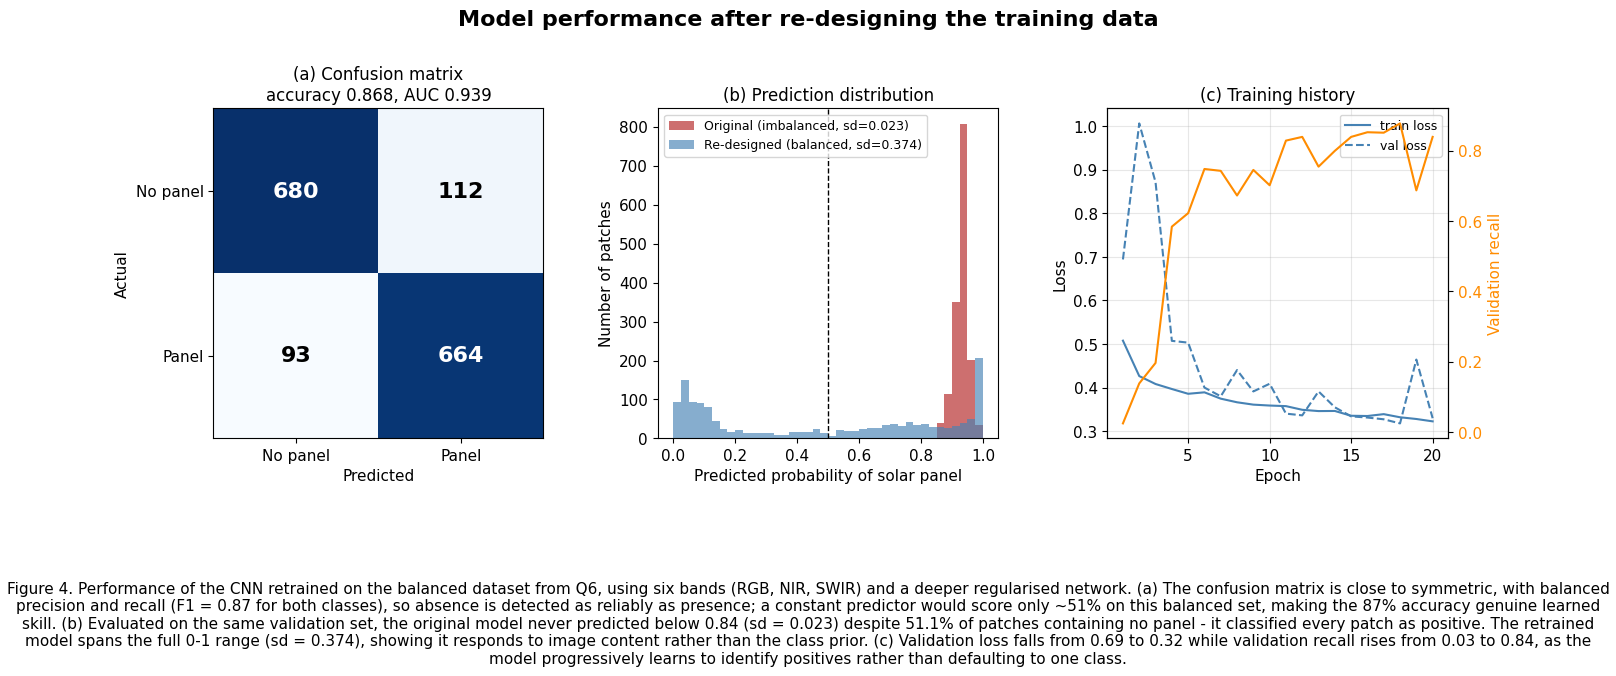

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Q7 Figure: model performance after re-designed training data

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score

# Real predictions from the ORIGINAL model on the same validation set
old_prob = model.predict(X_va[..., :3], verbose=0).ravel()

cm  = confusion_matrix(Y_va, Y_pred)
auc = roc_auc_score(Y_va, Y_prob)
acc = (Y_pred == Y_va).mean()
pct_no_panel = (1 - Y_va.mean()) * 100      # computed live so it can't drift

plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(16, 5.5))
gs = fig.add_gridspec(1, 3, wspace=0.32)

# (a) Confusion matrix heatmap
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['No panel', 'Panel'])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(['No panel', 'Panel'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title(f'(a) Confusion matrix\naccuracy {acc:.3f}, AUC {auc:.3f}', fontsize=12)
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i,j]}', ha='center', va='center', fontsize=16,
                 fontweight='bold',
                 color='white' if cm[i, j] > thresh else 'black')

# (b) Prediction distribution: original vs re-designed (both real)
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(old_prob, bins=40, range=(0, 1), alpha=0.65, color='firebrick',
         label=f'Original (imbalanced, sd={old_prob.std():.3f})')
ax2.hist(Y_prob, bins=40, range=(0, 1), alpha=0.65, color='steelblue',
         label=f'Re-designed (balanced, sd={Y_prob.std():.3f})')
ax2.axvline(0.5, ls='--', c='k', lw=1)
ax2.set_xlabel('Predicted probability of solar panel')
ax2.set_ylabel('Number of patches')
ax2.set_title('(b) Prediction distribution', fontsize=12)
ax2.legend(fontsize=9)

# (c) Training curves
ax3 = fig.add_subplot(gs[0, 2])
ep = range(1, len(history2.history['loss']) + 1)
ax3.plot(ep, history2.history['loss'], label='train loss', color='steelblue')
ax3.plot(ep, history2.history['val_loss'], label='val loss',
         color='steelblue', ls='--')
ax3b = ax3.twinx()
ax3b.plot(ep, history2.history['val_recall'], label='val recall', color='darkorange')
ax3b.set_ylabel('Validation recall', color='darkorange')
ax3b.tick_params(axis='y', labelcolor='darkorange')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.set_title('(c) Training history', fontsize=12)
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(alpha=0.3)

fig.suptitle('Model performance after re-designing the training data',
             fontsize=16, fontweight='bold', y=1.0)

caption = (
    'Figure 4. Performance of the CNN retrained on the balanced dataset from Q6, using six bands '
    '(RGB, NIR, SWIR) and a deeper regularised network. (a) The confusion matrix is close to '
    'symmetric, with balanced precision and recall (F1 = 0.87 for both classes), so absence is '
    'detected as reliably as presence; a constant predictor would score only ~51% on this balanced '
    'set, making the 87% accuracy genuine learned skill. (b) Evaluated on the same validation set, '
    f'the original model never predicted below {old_prob.min():.2f} (sd = {old_prob.std():.3f}) '
    f'despite {pct_no_panel:.1f}% of patches containing no panel - it classified every patch as '
    f'positive. The retrained model spans the full 0-1 range (sd = {Y_prob.std():.3f}), showing it '
    'responds to image content rather than the class prior. (c) Validation loss falls from 0.69 to '
    '0.32 while validation recall rises from 0.03 to 0.84, as the model progressively learns to '
    'identify positives rather than defaulting to one class.'
)
fig.text(0.5, -0.04, caption, ha='center', va='top', wrap=True, fontsize=11)

fig.subplots_adjust(bottom=0.22, top=0.82)
fig.savefig('model_performance_q7.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('model_performance_q7.png')

# Answer:
**Changes and Reasoning:**
I replaced the artificially capped 500-patch subset with a balanced 6196-patch set (3098 positive / 3098 negative), built by mining 64 X 64 sub-patches from the original imagery and labelling each by whether its mask region contains at least five solar pixels.
The original set was 93.4% positive, with too few negatives to learn from, so the network could minimise loss by always predicting "panel"; adding genuine negatives forces a real decision boundary and makes accuracy interpretable. The shuffled 75/25 split produced near identical class proportions on both sides (50.4% train and 48.9% validation positive), so the validation metrics are meaningful. I also expanded the input from 3 to 6 bands (RGB + NIR + SWIR), since panels are only subtly separable in the visible at 10m, but stand out more in NIR/SWIR and because the sub-patches were cropped from the original multi-band scenes, these bands were available at no extra sampling cost. Finally, I used a deeper regularised CNN trained for 20 epochs with EarlyStopping on validation loss, giving the harder balanced task more capacity while guarding against overfitting

**Results:**
On the balanced validation set the model reaches 0.868 accuracy, 0.939 AUC and an F1 of 0.87 for both classes, with roughly symmetric precision and recall, so absence is now detected about as reliably as presence. Because a majority-class constant predictor would score only ~51% on this set, the 0.868 reflects learned skill rather than the base rate, which is exactly what the original imbalanced model's "high accuracy" failed to do. The prediction-distribution panel makes the change concrete: the original model's outputs never fell below 0.84 (sd 0.023) despite 51.1% of patches being negative, whereas the retrained model spans the full 0-1 range (sd 0.374) and responds to image content. Over training, validation recall rose from 0.03 to ~0.84 and validation loss fell from 0.69 to 0.32, showing the model progressively learned to identify positives instead of defaulting to one class. The training-data redesign is what produced the difference; the earlier result was a degenerate artefact of imbalance, and once negatives were present the standard metrics became informative. Because balance and band count were changed together, their individual contributions cannot be separated, an RGB-only balanced ablation would isolate them.